In [19]:
import glob
import numpy as np
import pandas as pd
import polars as pl
import math
import itertools 

from xgboost import XGBClassifier
XGBOOST_AVAILABLE = True
from sklearn.model_selection import train_test_split

#matplotlib libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import seaborn as sns

#date libraries
from dateutil import parser
from datetime import datetime, timedelta, date


#p

#pandas options
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)  

pl.Config.set_tbl_cols(-1)     # show all columns, no truncation
pl.Config.set_tbl_rows(20)     # cap rows shown (avoid dumping 7M rows)
pl.Config.set_fmt_str_lengths(50)

#matplotlib setting defaults
sns.set(font="Arial",
        rc={
 "axes.axisbelow": False,
 "axes.edgecolor": "lightgrey",
 "axes.facecolor": "None",
 "axes.grid": False,
 "axes.labelcolor": "dimgrey",
 "axes.spines.right": False,
 "axes.spines.top": False,
 "figure.facecolor": "white",
 "lines.solid_capstyle": "round",
 "patch.edgecolor": "w",
 "patch.force_edgecolor": True,
 "text.color": "dimgrey",
 "xtick.bottom": False,
 "xtick.color": "dimgrey",
 "xtick.direction": "out",
 "xtick.top": False,
 "ytick.color": "dimgrey",
 "ytick.direction": "out",
 "ytick.left": False,
 "ytick.right": False})

In [20]:
def missing_data(input_data: pl.DataFrame) -> pl.DataFrame:
    '''
    Returns a dataframe with % nulls and dtype per column.
    input: polars df
    output: polars df
    '''
    total = input_data.null_count().to_pandas().T.rename(columns={0: "Total"})
    total["Percent"] = total["Total"] / input_data.height * 100
    total["Types"] = [str(dt) for dt in input_data.dtypes]
    return total

def mape(actual, pred):
    '''
    Mean Absolute Percentage Error (MAPE)
    input: array-like actual and predicted values
    output: mape value
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [21]:
air_data = glob.glob("bts_raw_data/*.zip")

In [22]:
import io
import zipfile

NEEDED = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek", "FlightDate",
    "Reporting_Airline", "Flight_Number_Reporting_Airline", "Tail_Number",
    "Origin", "OriginState", "Dest", "DestState",
    "CRSDepTime", "CRSArrTime", "DepTimeBlk", "ArrTimeBlk",
    "CRSElapsedTime", "Distance", "DistanceGroup",
    "DepDel15", "ArrDel15", "DepDelayMinutes", "ArrDelayMinutes", "Cancelled", "Diverted",
]

frames = []
for zip_path in air_data:
    with zipfile.ZipFile(zip_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.lower().endswith('.csv'))
        with archive.open(csv_name) as csv_file:
            frames.append(pl.read_csv(io.BytesIO(csv_file.read()), columns=NEEDED))

air_data = pl.concat(frames, how="diagonal_relaxed")
DAYS = 365
last_day = pd.to_datetime(air_data["FlightDate"].cast(pl.Utf8).max())
start_day = (last_day - pd.Timedelta(days=DAYS)).strftime("%Y-%m-%d")
air_data = air_data.filter(pl.col("FlightDate").cast(pl.Utf8) >= start_day)
print(air_data.shape)


(7018226, 26)


In [23]:
air_data.columns 

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'DepDelayMinutes',
 'DepDel15',
 'DepTimeBlk',
 'CRSArrTime',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrTimeBlk',
 'Cancelled',
 'Diverted',
 'CRSElapsedTime',
 'Distance',
 'DistanceGroup']

In [24]:
feature_cols = [
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Tail_Number",
    "Origin",
    "OriginState",
    "Dest",
    "DestState",
    "CRSDepTime",
    "CRSArrTime",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
]


In [25]:
import gc

# Columns needed by everything downstream (model features/targets + rolling-state inputs)
keep_cols = list(dict.fromkeys(
    feature_cols + target_cols
    + ["FlightDate", "OriginState", "DestState", "ArrDelayMinutes", "DepDelayMinutes"]
))

dep = pl.col("CRSDepTime").cast(pl.Int32, strict=False)

ctx = (
    air_data.select(keep_cols)
    .with_columns(
        # midnight + (hh*60 + mm) minutes; also handles CRSDepTime == 2400 correctly
        (
            pl.col("FlightDate").cast(pl.Utf8).str.to_datetime("%Y-%m-%d", strict=False)
            + pl.duration(minutes=(dep // 100) * 60 + dep % 100)
        ).alias("PredictionTime"),
        pl.col("DepDelayMinutes").cast(pl.Float32, strict=False),
        pl.col("ArrDelayMinutes").cast(pl.Float32, strict=False),
        pl.col("Cancelled").cast(pl.Float32, strict=False).fill_null(0),
        pl.col("Diverted").cast(pl.Float32, strict=False).fill_null(0),
    )
    .with_columns(
        (pl.col("DepDelayMinutes") >= 15).fill_null(False).cast(pl.Int8).alias("DepDelayed"),
        (pl.col("ArrDelayMinutes") >= 15).fill_null(False).cast(pl.Int8).alias("ArrDelayed"),
        (pl.col("Origin") + "_" + pl.col("Dest")).alias("Route"),
        (pl.col("OriginState") + "_" + pl.col("DestState")).alias("StateRoute"),
    )
    .drop_nulls("PredictionTime")
    .sort("PredictionTime")
)

context_df = ctx.to_pandas()
del ctx
gc.collect()

print(context_df.shape)
print(f"{context_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

(7018226, 29)
5.61 GB


In [26]:
import numpy as np
import pandas as pd

LAG_HOURS = 2
WINDOWS = (1, 3, 6, 12, 24)

def add_rolling_context(df, key_col, prefix, metrics, volume_suffix=None,
                        lag=LAG_HOURS, windows=WINDOWS):
    """
    For each flight, summarize the same key (airport / route / state route) over the
    window of hours ending `lag` hours before its scheduled departure hour.
    Uses cumulative sums + searchsorted, so there are no merges, no duplicate-index
    problems, and the current flight can't be in its own window.
    metrics: {feature_suffix: source_column}, averaged over the window.
    """
    key_id = pd.factorize(df[key_col])[0].astype("int64")
    OFFSET = 100
    BIG = int(df["hour_idx"].max()) + 2 * OFFSET
    q = key_id * BIG + df["hour_idx"].to_numpy() + OFFSET

    tmp = pd.DataFrame({"k": q, "n": 1})
    for suffix, col in metrics.items():
        v = df[col].to_numpy(dtype="float64")
        tmp[f"{suffix}_s"] = np.nan_to_num(v)
        tmp[f"{suffix}_c"] = (~np.isnan(v)).astype("int64")

    g = tmp.groupby("k", sort=True).sum()
    del tmp
    keys = g.index.to_numpy()
    cs = {c: np.concatenate([[0.0], np.cumsum(g[c].to_numpy(dtype="float64"))]) for c in g.columns}

    new = {}
    for w in windows:
        i0 = np.searchsorted(keys, q - lag - w + 1, side="left")
        i1 = np.searchsorted(keys, q - lag, side="right")
        if volume_suffix:
            new[f"{prefix}_{volume_suffix}_{w}h"] = (cs["n"][i1] - cs["n"][i0]).astype("float32")
        for suffix in metrics:
            s = cs[f"{suffix}_s"][i1] - cs[f"{suffix}_s"][i0]
            c = cs[f"{suffix}_c"][i1] - cs[f"{suffix}_c"][i0]
            new[f"{prefix}_{suffix}_{w}h"] = np.where(c > 0, s / np.maximum(c, 1), np.nan).astype("float32")
    return pd.DataFrame(new, index=df.index)

In [27]:
# ---------------------------------------------------------
# BUILD TEMPORAL CONTEXT USING ALL AVAILABLE FLIGHTS
# ---------------------------------------------------------

context_df = (
    context_df
    .sort_values("PredictionTime")
    .reset_index(drop=True)
)

t0 = context_df["PredictionTime"].min().floor("h")

context_df["hour_idx"] = (
    (context_df["PredictionTime"].dt.floor("h") - t0)
    // pd.Timedelta("1h")
).astype("int64")

print("Rows used for context construction:", len(context_df))

parts = [
    add_rolling_context(
        context_df, "Origin", "airport",
        {"avg_dep_delay": "DepDelayMinutes", "dep_delay_rate": "DepDelayed",
         "cancel_rate": "Cancelled", "diversion_rate": "Diverted"},
        volume_suffix="flight_volume",
    ),
    add_rolling_context(
        context_df, "Dest", "dest_airport",
        {"avg_arr_delay": "ArrDelayMinutes", "arr_delay_rate": "ArrDelayed",
         "cancel_rate": "Cancelled", "diversion_rate": "Diverted"},
    ),
    add_rolling_context(
        context_df, "Route", "route",
        {"avg_delay": "DepDelayMinutes", "delay_rate": "DepDelayed", "cancel_rate": "Cancelled"},
    ),
    add_rolling_context(
        context_df, "StateRoute", "state_route",
        {"avg_delay": "DepDelayMinutes", "delay_rate": "DepDelayed", "cancel_rate": "Cancelled"},
    ),
]

context_df = pd.concat([context_df] + parts, axis=1)
del parts
gc.collect()


Rows used for context construction: 7018226


27

In [28]:
context_feature_cols = [
    col for col in context_df.columns
    if col.startswith((
        "airport_",
        "dest_airport_",
        "route_",
        "state_route_"
    ))
]

df = context_df[
    ["FlightDate", "PredictionTime"]
    + feature_cols
    + target_cols
    + context_feature_cols
].copy()


In [29]:
plane_df = context_df[["Tail_Number", "PredictionTime", "CRSElapsedTime", "FlightDate",
                       "ArrDelayMinutes", "Cancelled", "Diverted"]].copy()
plane_df["Tail_Number"] = plane_df["Tail_Number"].fillna("UNKNOWN")
plane_df = plane_df.sort_values(["Tail_Number", "PredictionTime"])

by_plane = plane_df.groupby("Tail_Number")
prev_arr_delay = by_plane["ArrDelayMinutes"].shift(1)
prev_cancelled = by_plane["Cancelled"].shift(1)
prev_diverted = by_plane["Diverted"].shift(1)
prev_landing = by_plane["PredictionTime"].shift(1) + pd.to_timedelta(by_plane["CRSElapsedTime"].shift(1), unit="m")

# Minutes between the last flight's scheduled landing and this flight's scheduled departure
gap = (plane_df["PredictionTime"] - prev_landing).dt.total_seconds() / 60

has_plane = plane_df["Tail_Number"] != "UNKNOWN"
landed = (prev_arr_delay <= gap) & has_plane        # only trust the delay if it had already landed

plane_features = pd.DataFrame(index=plane_df.index)
plane_features["plane_prev_arr_delay"] = prev_arr_delay.where(landed)          # NaN when unknown
plane_features["plane_prev_known"] = landed
plane_features["plane_prev_cancelled"] = (prev_cancelled == 1) & has_plane
plane_features["plane_prev_diverted"] = (prev_diverted == 1) & (gap >= 0) & has_plane
plane_features["plane_turnaround"] = gap.clip(0, 720).where(has_plane)         # scheduled minutes on the ground
plane_features["plane_leg_of_day"] = plane_df.groupby(["Tail_Number", "FlightDate"]).cumcount().where(has_plane)
plane_features = plane_features.astype("float32")

for col in plane_features.columns:
    df[col] = plane_features[col]                  # lines up by row label, so order doesn't matter

del plane_df, plane_features, by_plane
gc.collect()

print(df.filter(like="plane_").describe().T)
# ---------------------------------------------------------
# CONTEXT IS NOW COMPLETE. SAMPLE ONLY THE MODELING DATASET
# ---------------------------------------------------------

MAX_MODEL_ROWS = 1_500_000

if len(df) > MAX_MODEL_ROWS:
    sample_idx = np.random.RandomState(42).choice(
        len(df),
        MAX_MODEL_ROWS,
        replace=False
    )
    df = df.iloc[sample_idx].copy()

df = df.sort_values("PredictionTime").reset_index(drop=True)

print("Final modeling rows:", len(df))
print("Final modeling columns:", len(df.columns))


del context_df, air_data
gc.collect()


                          count   mean    std  min   25%   50%    75%     max
plane_prev_arr_delay 5629094.00  12.44  43.13 0.00  0.00  0.00   7.00 4336.00
plane_prev_known     7018226.00   0.80   0.40 0.00  1.00  1.00   1.00    1.00
plane_prev_cancelled 7018226.00   0.01   0.12 0.00  0.00  0.00   0.00    1.00
plane_prev_diverted  7018226.00   0.00   0.05 0.00  0.00  0.00   0.00    1.00
plane_turnaround     7011988.00 194.66 235.07 0.00 40.00 72.00 305.00  720.00
plane_leg_of_day     7018226.00   2.00   4.51 0.00  1.00  2.00   3.00  463.00
Final modeling rows: 1500000
Final modeling columns: 106


0

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

ctx_feature_cols = [
    c for c in df.columns
    if c.startswith((
        "airport_",
        "dest_airport_",
        "route_",
        "state_route_",
        "plane_"
    ))
]

model_cols = [
    c for c in feature_cols
    if c != "Tail_Number"
] + ctx_feature_cols

cat_cols_used = [
    c for c in categorical_cols
    if c != "Tail_Number"
]
X = df[model_cols].copy()

for col in cat_cols_used:
    X[col] = (
        X[col]
        .astype("category")
        .cat.codes
        .astype("int16")
    )

y = np.where(
    df["Cancelled"] == 1,
    2,
    df["DepDel15"]
)

keep = ~pd.isna(y)

X = X.loc[keep].reset_index(drop=True)
y = y[keep].astype(np.int8)

print("Model dataset:", X.shape)
print("Target distribution:")
print(pd.Series(y).value_counts(normalize=True).sort_index())

dates = pd.to_datetime(
    df.loc[keep, "FlightDate"],
    errors="coerce"
).reset_index(drop=True)

split_date = dates.quantile(0.80)
train_mask = dates < split_date
test_mask = dates >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Split date:", split_date)

air_xgb_model = XGBClassifier(
    tree_method="hist",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=128,
    n_jobs=4,
    random_state=42,
    eval_metric="mlogloss"
)

air_xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

from pathlib import Path
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
air_xgb_model.save_model(MODEL_DIR / "air_xgb_model.json")

type_prediction = air_xgb_model.predict(X_test)

print("\n==============================")
print("AEROPROPHET XGBOOST RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_test, type_prediction))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, type_prediction))
print("\nClassification Report:")
print(classification_report(
    y_test,
    type_prediction,
    target_names=["On Time", "Delayed", "Cancelled"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, type_prediction))


Model dataset: (1500000, 97)
Target distribution:
0   0.77
1   0.21
2   0.01
Name: proportion, dtype: float64
Train: (1198721, 97)
Test : (301279, 97)
Split date: 2025-10-19 00:00:00

AEROPROPHET XGBOOST RESULTS
Accuracy: 0.8404900441119361
Balanced Accuracy: 0.6048663371874233

Classification Report:
              precision    recall  f1-score   support

     On Time       0.86      0.96      0.90    227369
     Delayed       0.76      0.48      0.59     68421
   Cancelled       0.76      0.37      0.50      5489

    accuracy                           0.84    301279
   macro avg       0.79      0.60      0.66    301279
weighted avg       0.83      0.84      0.83    301279


Confusion Matrix:
[[218211   8921    237]
 [ 35055  32963    403]
 [  1947   1494   2048]]


In [31]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid DepDel15 target
model_df = df.dropna(subset=["DepDel15"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["DepDel15"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
depdel15_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
depdel15_model.fit(X_train, y_train)

# Predict
depdel15_prediction = depdel15_model.predict(X_test)

# Evaluate
print("DepDel15 Accuracy:", accuracy_score(y_test, depdel15_prediction))
print(classification_report(y_test, depdel15_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = depdel15_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
depdel15_model.save_model(MODEL_DIR / "depdel15_model.json")


DepDel15 Accuracy: 0.84467
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90    153696
         1.0       0.74      0.50      0.60     46304

    accuracy                           0.84    200000
   macro avg       0.80      0.72      0.75    200000
weighted avg       0.84      0.84      0.83    200000

ROC-AUC: 0.8240739665654175
PR-AUC: 0.6989213378774551
Base rate (PR-AUC of random guessing): 0.23152


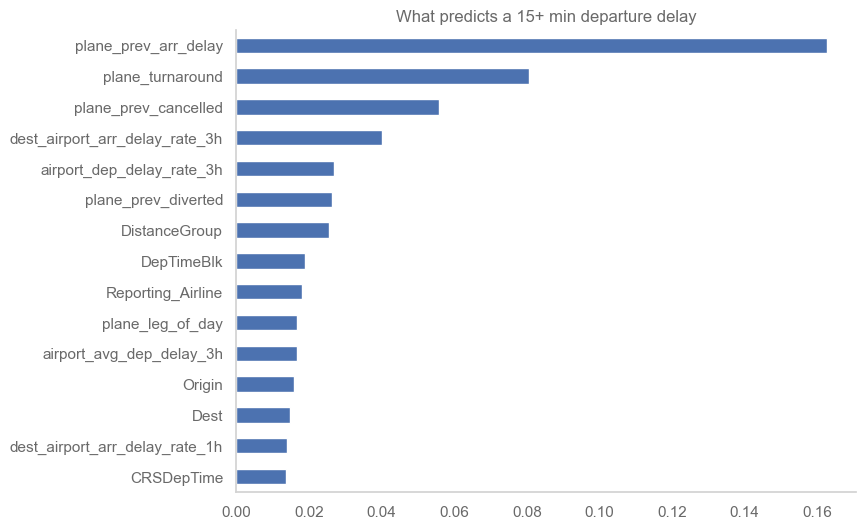

In [33]:
imp = pd.Series(depdel15_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
imp.sort_values().plot.barh(figsize=(8, 6), title="What predicts a 15+ min departure delay")
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
base_cols = [c for c in feature_cols if c != "Tail_Number"]
no_ctx_model = XGBClassifier(n_estimators=300, max_depth=8, n_jobs=4, random_state=1, enable_categorical=True)
no_ctx_model.fit(X_train[base_cols], y_train)
print("ROC-AUC without context features:", roc_auc_score(y_test, no_ctx_model.predict_proba(X_test[base_cols])[:, 1]))
print("ROC-AUC with context features:   ", roc_auc_score(y_test, depdel15_model.predict_proba(X_test)[:, 1]))

ROC-AUC without context features: 0.6169307461904173
ROC-AUC with context features:    0.8240739665654175


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid Cancelled target
model_df = df.dropna(subset=["Cancelled"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["Cancelled"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
cancelled_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
cancelled_model.fit(X_train, y_train)

# Predict
cancelled_prediction = cancelled_model.predict(X_test)

# Evaluate
print("Cancelled Accuracy:", accuracy_score(y_test, cancelled_prediction))
print(classification_report(y_test, cancelled_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = cancelled_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
cancelled_model.save_model(MODEL_DIR / "cancelled_model.json")


Cancelled Accuracy: 0.98622
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    196290
         1.0       0.81      0.34      0.48      3710

    accuracy                           0.99    200000
   macro avg       0.90      0.67      0.73    200000
weighted avg       0.98      0.99      0.98    200000

ROC-AUC: 0.9238638914945007
PR-AUC: 0.5535074736842969
Base rate (PR-AUC of random guessing): 0.01855


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid Diverted target
model_df = df.dropna(subset=["Diverted"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["Diverted"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
diverted_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
diverted_model.fit(X_train, y_train)

# Predict
diverted_prediction = diverted_model.predict(X_test)

# Evaluate
print("Diverted Accuracy:", accuracy_score(y_test, diverted_prediction))
print(classification_report(y_test, diverted_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = diverted_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
diverted_model.save_model(MODEL_DIR / "diverted_model.json")


Diverted Accuracy: 0.99784
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    199569
         1.0       0.00      0.00      0.00       431

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.7232446769656359
PR-AUC: 0.01613367611278272
Base rate (PR-AUC of random guessing): 0.002155


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Only keep flights that have a valid DepDelayMinutes target
model_df = df.dropna(subset=["DepDelayMinutes"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["DepDelayMinutes"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
depdelay_minutes_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
depdelay_minutes_model.fit(X_train, y_train)

# Predict
depdelay_minutes_prediction = depdelay_minutes_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, depdelay_minutes_prediction)
print("DepDelayMinutes MAE:", mae)
print("MAE:", mae)
print("Baseline MAE (always guess median):", mean_absolute_error(y_test, np.full(len(y_test), y_train.median())))
print("Mean actual delay:", y_test.mean())
print("Median actual delay:", y_test.median())
print("Max actual delay:", y_test.max())

# Save
depdelay_minutes_model.save_model(MODEL_DIR / "depdelay_minutes_model.json")


DepDelayMinutes MAE: 20.96924591064453
MAE: 20.96924591064453
Baseline MAE (always guess median): 18.062440872192383
Mean actual delay: 18.06244
Median actual delay: 0.0
Max actual delay: 2601.0


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Only keep flights that have a valid ArrDelayMinutes target
model_df = df.dropna(subset=["ArrDelayMinutes"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["ArrDelayMinutes"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
arrdelay_minutes_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
arrdelay_minutes_model.fit(X_train, y_train)

# Predict
arrdelay_minutes_prediction = arrdelay_minutes_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, arrdelay_minutes_prediction)
print("ArrDelayMinutes MAE:", mae)
print("MAE:", mae)
print("Baseline MAE (always guess median):", mean_absolute_error(y_test, np.full(len(y_test), y_train.median())))
print("Mean actual delay:", y_test.mean())
print("Median actual delay:", y_test.median())
print("Max actual delay:", y_test.max())

# Save
arrdelay_minutes_model.save_model(MODEL_DIR / "arrdelay_minutes_model.json")


ArrDelayMinutes MAE: 21.99658203125
MAE: 21.99658203125
Baseline MAE (always guess median): 18.341190338134766
Mean actual delay: 18.34119
Median actual delay: 0.0
Max actual delay: 2617.0


In [ ]:
def missing_data(input_data: pl.DataFrame) -> pl.DataFrame:
    '''
    Returns a dataframe with % nulls and dtype per column.
    input: polars df
    output: polars df
    '''
    total = input_data.null_count().to_pandas().T.rename(columns={0: "Total"})
    total["Percent"] = total["Total"] / input_data.height * 100
    total["Types"] = [str(dt) for dt in input_data.dtypes]
    return total

def mape(actual, pred):
    '''
    Mean Absolute Percentage Error (MAPE)
    input: array-like actual and predicted values
    output: mape value
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [ ]:
air_data = glob.glob("bts_raw_data/*.zip")

In [ ]:
import io
import zipfile

NEEDED = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek", "FlightDate",
    "Reporting_Airline", "Flight_Number_Reporting_Airline", "Tail_Number",
    "Origin", "OriginState", "Dest", "DestState",
    "CRSDepTime", "CRSArrTime", "DepTimeBlk", "ArrTimeBlk",
    "CRSElapsedTime", "Distance", "DistanceGroup",
    "DepDel15", "ArrDel15", "DepDelayMinutes", "ArrDelayMinutes", "Cancelled", "Diverted",
]

frames = []
for zip_path in air_data:
    with zipfile.ZipFile(zip_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.lower().endswith('.csv'))
        with archive.open(csv_name) as csv_file:
            frames.append(pl.read_csv(io.BytesIO(csv_file.read()), columns=NEEDED))

air_data = pl.concat(frames, how="diagonal_relaxed")
DAYS = 365
last_day = pd.to_datetime(air_data["FlightDate"].cast(pl.Utf8).max())
start_day = (last_day - pd.Timedelta(days=DAYS)).strftime("%Y-%m-%d")
air_data = air_data.filter(pl.col("FlightDate").cast(pl.Utf8) >= start_day)
print(air_data.shape)


(7018226, 26)


In [ ]:
air_data.columns 

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'Origin',
 'OriginState',
 'Dest',
 'DestState',
 'CRSDepTime',
 'DepDelayMinutes',
 'DepDel15',
 'DepTimeBlk',
 'CRSArrTime',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrTimeBlk',
 'Cancelled',
 'Diverted',
 'CRSElapsedTime',
 'Distance',
 'DistanceGroup']

In [ ]:
feature_cols = [
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Tail_Number",
    "Origin",
    "OriginState",
    "Dest",
    "DestState",
    "CRSDepTime",
    "CRSArrTime",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
]


In [ ]:
import gc

# Columns needed by everything downstream (model features/targets + rolling-state inputs)
keep_cols = list(dict.fromkeys(
    feature_cols + target_cols
    + ["FlightDate", "OriginState", "DestState", "ArrDelayMinutes", "DepDelayMinutes"]
))

dep = pl.col("CRSDepTime").cast(pl.Int32, strict=False)

ctx = (
    air_data.select(keep_cols)
    .with_columns(
        # midnight + (hh*60 + mm) minutes; also handles CRSDepTime == 2400 correctly
        (
            pl.col("FlightDate").cast(pl.Utf8).str.to_datetime("%Y-%m-%d", strict=False)
            + pl.duration(minutes=(dep // 100) * 60 + dep % 100)
        ).alias("PredictionTime"),
        pl.col("DepDelayMinutes").cast(pl.Float32, strict=False),
        pl.col("ArrDelayMinutes").cast(pl.Float32, strict=False),
        pl.col("Cancelled").cast(pl.Float32, strict=False).fill_null(0),
        pl.col("Diverted").cast(pl.Float32, strict=False).fill_null(0),
    )
    .with_columns(
        (pl.col("DepDelayMinutes") >= 15).fill_null(False).cast(pl.Int8).alias("DepDelayed"),
        (pl.col("ArrDelayMinutes") >= 15).fill_null(False).cast(pl.Int8).alias("ArrDelayed"),
        (pl.col("Origin") + "_" + pl.col("Dest")).alias("Route"),
        (pl.col("OriginState") + "_" + pl.col("DestState")).alias("StateRoute"),
    )
    .drop_nulls("PredictionTime")
    .sort("PredictionTime")
)

context_df = ctx.to_pandas()
del ctx
gc.collect()

print(context_df.shape)
print(f"{context_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

(7018226, 29)
5.61 GB


In [ ]:
import numpy as np
import pandas as pd

LAG_HOURS = 2
WINDOWS = (1, 3, 6, 12, 24)

def add_rolling_context(df, key_col, prefix, metrics, volume_suffix=None,
                        lag=LAG_HOURS, windows=WINDOWS):
    """
    For each flight, summarize the same key (airport / route / state route) over the
    window of hours ending `lag` hours before its scheduled departure hour.
    Uses cumulative sums + searchsorted, so there are no merges, no duplicate-index
    problems, and the current flight can't be in its own window.
    metrics: {feature_suffix: source_column}, averaged over the window.
    """
    key_id = pd.factorize(df[key_col])[0].astype("int64")
    OFFSET = 100
    BIG = int(df["hour_idx"].max()) + 2 * OFFSET
    q = key_id * BIG + df["hour_idx"].to_numpy() + OFFSET

    tmp = pd.DataFrame({"k": q, "n": 1})
    for suffix, col in metrics.items():
        v = df[col].to_numpy(dtype="float64")
        tmp[f"{suffix}_s"] = np.nan_to_num(v)
        tmp[f"{suffix}_c"] = (~np.isnan(v)).astype("int64")

    g = tmp.groupby("k", sort=True).sum()
    del tmp
    keys = g.index.to_numpy()
    cs = {c: np.concatenate([[0.0], np.cumsum(g[c].to_numpy(dtype="float64"))]) for c in g.columns}

    new = {}
    for w in windows:
        i0 = np.searchsorted(keys, q - lag - w + 1, side="left")
        i1 = np.searchsorted(keys, q - lag, side="right")
        if volume_suffix:
            new[f"{prefix}_{volume_suffix}_{w}h"] = (cs["n"][i1] - cs["n"][i0]).astype("float32")
        for suffix in metrics:
            s = cs[f"{suffix}_s"][i1] - cs[f"{suffix}_s"][i0]
            c = cs[f"{suffix}_c"][i1] - cs[f"{suffix}_c"][i0]
            new[f"{prefix}_{suffix}_{w}h"] = np.where(c > 0, s / np.maximum(c, 1), np.nan).astype("float32")
    return pd.DataFrame(new, index=df.index)

In [ ]:
# ---------------------------------------------------------
# BUILD TEMPORAL CONTEXT USING ALL AVAILABLE FLIGHTS
# ---------------------------------------------------------

context_df = (
    context_df
    .sort_values("PredictionTime")
    .reset_index(drop=True)
)

t0 = context_df["PredictionTime"].min().floor("h")

context_df["hour_idx"] = (
    (context_df["PredictionTime"].dt.floor("h") - t0)
    // pd.Timedelta("1h")
).astype("int64")

print("Rows used for context construction:", len(context_df))

parts = [
    add_rolling_context(
        context_df, "Origin", "airport",
        {"avg_dep_delay": "DepDelayMinutes", "dep_delay_rate": "DepDelayed",
         "cancel_rate": "Cancelled", "diversion_rate": "Diverted"},
        volume_suffix="flight_volume",
    ),
    add_rolling_context(
        context_df, "Dest", "dest_airport",
        {"avg_arr_delay": "ArrDelayMinutes", "arr_delay_rate": "ArrDelayed",
         "cancel_rate": "Cancelled", "diversion_rate": "Diverted"},
    ),
    add_rolling_context(
        context_df, "Route", "route",
        {"avg_delay": "DepDelayMinutes", "delay_rate": "DepDelayed", "cancel_rate": "Cancelled"},
    ),
    add_rolling_context(
        context_df, "StateRoute", "state_route",
        {"avg_delay": "DepDelayMinutes", "delay_rate": "DepDelayed", "cancel_rate": "Cancelled"},
    ),
]

context_df = pd.concat([context_df] + parts, axis=1)
del parts
gc.collect()


Rows used for context construction: 7018226


27

In [ ]:
context_feature_cols = [
    col for col in context_df.columns
    if col.startswith((
        "airport_",
        "dest_airport_",
        "route_",
        "state_route_"
    ))
]

df = context_df[
    ["FlightDate", "PredictionTime"]
    + feature_cols
    + target_cols
    + context_feature_cols
].copy()


In [ ]:
plane_df = context_df[["Tail_Number", "PredictionTime", "CRSElapsedTime", "FlightDate",
                       "ArrDelayMinutes", "Cancelled", "Diverted"]].copy()
plane_df["Tail_Number"] = plane_df["Tail_Number"].fillna("UNKNOWN")
plane_df = plane_df.sort_values(["Tail_Number", "PredictionTime"])

by_plane = plane_df.groupby("Tail_Number")
prev_arr_delay = by_plane["ArrDelayMinutes"].shift(1)
prev_cancelled = by_plane["Cancelled"].shift(1)
prev_diverted = by_plane["Diverted"].shift(1)
prev_landing = by_plane["PredictionTime"].shift(1) + pd.to_timedelta(by_plane["CRSElapsedTime"].shift(1), unit="m")

# Minutes between the last flight's scheduled landing and this flight's scheduled departure
gap = (plane_df["PredictionTime"] - prev_landing).dt.total_seconds() / 60

has_plane = plane_df["Tail_Number"] != "UNKNOWN"
landed = (prev_arr_delay <= gap) & has_plane        # only trust the delay if it had already landed

plane_features = pd.DataFrame(index=plane_df.index)
plane_features["plane_prev_arr_delay"] = prev_arr_delay.where(landed)          # NaN when unknown
plane_features["plane_prev_known"] = landed
plane_features["plane_prev_cancelled"] = (prev_cancelled == 1) & has_plane
plane_features["plane_prev_diverted"] = (prev_diverted == 1) & (gap >= 0) & has_plane
plane_features["plane_turnaround"] = gap.clip(0, 720).where(has_plane)         # scheduled minutes on the ground
plane_features["plane_leg_of_day"] = plane_df.groupby(["Tail_Number", "FlightDate"]).cumcount().where(has_plane)
plane_features = plane_features.astype("float32")

for col in plane_features.columns:
    df[col] = plane_features[col]                  # lines up by row label, so order doesn't matter

del plane_df, plane_features, by_plane
gc.collect()

print(df.filter(like="plane_").describe().T)
# ---------------------------------------------------------
# CONTEXT IS NOW COMPLETE. SAMPLE ONLY THE MODELING DATASET
# ---------------------------------------------------------

MAX_MODEL_ROWS = 1_500_000

if len(df) > MAX_MODEL_ROWS:
    sample_idx = np.random.RandomState(42).choice(
        len(df),
        MAX_MODEL_ROWS,
        replace=False
    )
    df = df.iloc[sample_idx].copy()

df = df.sort_values("PredictionTime").reset_index(drop=True)

print("Final modeling rows:", len(df))
print("Final modeling columns:", len(df.columns))


del context_df, air_data
gc.collect()


                          count   mean    std  min   25%   50%    75%     max
plane_prev_arr_delay 5629094.00  12.44  43.13 0.00  0.00  0.00   7.00 4336.00
plane_prev_known     7018226.00   0.80   0.40 0.00  1.00  1.00   1.00    1.00
plane_prev_cancelled 7018226.00   0.01   0.12 0.00  0.00  0.00   0.00    1.00
plane_prev_diverted  7018226.00   0.00   0.05 0.00  0.00  0.00   0.00    1.00
plane_turnaround     7011988.00 194.66 235.07 0.00 40.00 72.00 305.00  720.00
plane_leg_of_day     7018226.00   2.00   4.51 0.00  1.00  2.00   3.00  463.00
Final modeling rows: 1500000
Final modeling columns: 106


0

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

ctx_feature_cols = [
    c for c in df.columns
    if c.startswith((
        "airport_",
        "dest_airport_",
        "route_",
        "state_route_",
        "plane_"
    ))
]

model_cols = [
    c for c in feature_cols
    if c != "Tail_Number"
] + ctx_feature_cols

cat_cols_used = [
    c for c in categorical_cols
    if c != "Tail_Number"
]
X = df[model_cols].copy()

for col in cat_cols_used:
    X[col] = (
        X[col]
        .astype("category")
        .cat.codes
        .astype("int16")
    )

y = np.where(
    df["Cancelled"] == 1,
    2,
    df["DepDel15"]
)

keep = ~pd.isna(y)

X = X.loc[keep].reset_index(drop=True)
y = y[keep].astype(np.int8)

print("Model dataset:", X.shape)
print("Target distribution:")
print(pd.Series(y).value_counts(normalize=True).sort_index())

dates = pd.to_datetime(
    df.loc[keep, "FlightDate"],
    errors="coerce"
).reset_index(drop=True)

split_date = dates.quantile(0.80)
train_mask = dates < split_date
test_mask = dates >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Split date:", split_date)

air_xgb_model = XGBClassifier(
    tree_method="hist",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=128,
    n_jobs=4,
    random_state=42,
    eval_metric="mlogloss"
)

air_xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

from pathlib import Path
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
air_xgb_model.save_model(MODEL_DIR / "air_xgb_model.json")

type_prediction = air_xgb_model.predict(X_test)

print("\n==============================")
print("AEROPROPHET XGBOOST RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_test, type_prediction))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, type_prediction))
print("\nClassification Report:")
print(classification_report(
    y_test,
    type_prediction,
    target_names=["On Time", "Delayed", "Cancelled"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, type_prediction))


Model dataset: (1500000, 97)
Target distribution:
0   0.77
1   0.21
2   0.01
Name: proportion, dtype: float64
Train: (1198721, 97)
Test : (301279, 97)
Split date: 2025-10-19 00:00:00

AEROPROPHET XGBOOST RESULTS
Accuracy: 0.8404900441119361
Balanced Accuracy: 0.6048663371874233

Classification Report:
              precision    recall  f1-score   support

     On Time       0.86      0.96      0.90    227369
     Delayed       0.76      0.48      0.59     68421
   Cancelled       0.76      0.37      0.50      5489

    accuracy                           0.84    301279
   macro avg       0.79      0.60      0.66    301279
weighted avg       0.83      0.84      0.83    301279


Confusion Matrix:
[[218211   8921    237]
 [ 35055  32963    403]
 [  1947   1494   2048]]


In [ ]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid DepDel15 target
model_df = df.dropna(subset=["DepDel15"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["DepDel15"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
depdel15_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
depdel15_model.fit(X_train, y_train)

# Predict
depdel15_prediction = depdel15_model.predict(X_test)

# Evaluate
print("DepDel15 Accuracy:", accuracy_score(y_test, depdel15_prediction))
print(classification_report(y_test, depdel15_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = depdel15_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
depdel15_model.save_model(MODEL_DIR / "depdel15_model.json")


DepDel15 Accuracy: 0.84467
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90    153696
         1.0       0.74      0.50      0.60     46304

    accuracy                           0.84    200000
   macro avg       0.80      0.72      0.75    200000
weighted avg       0.84      0.84      0.83    200000

ROC-AUC: 0.8240739665654175
PR-AUC: 0.6989213378774551
Base rate (PR-AUC of random guessing): 0.23152


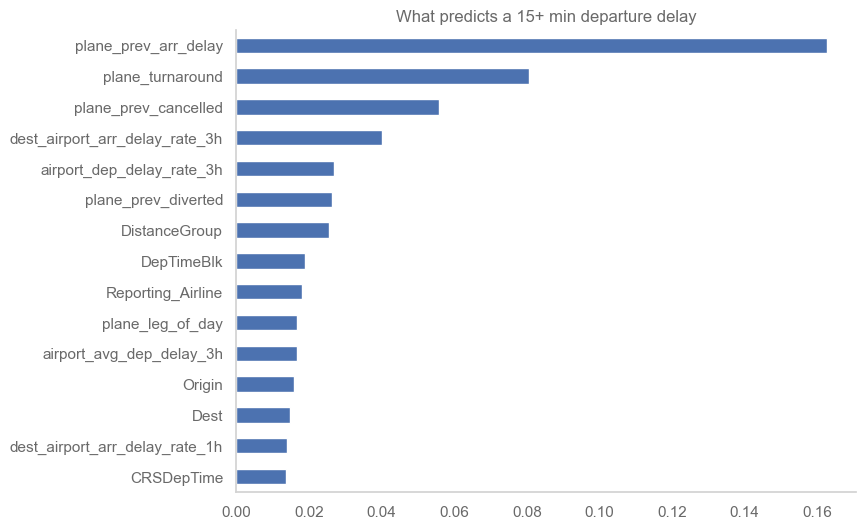

In [ ]:
imp = pd.Series(depdel15_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
imp.sort_values().plot.barh(figsize=(8, 6), title="What predicts a 15+ min departure delay")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
base_cols = [c for c in feature_cols if c != "Tail_Number"]
no_ctx_model = XGBClassifier(n_estimators=300, max_depth=8, n_jobs=4, random_state=1, enable_categorical=True)
no_ctx_model.fit(X_train[base_cols], y_train)
print("ROC-AUC without context features:", roc_auc_score(y_test, no_ctx_model.predict_proba(X_test[base_cols])[:, 1]))
print("ROC-AUC with context features:   ", roc_auc_score(y_test, depdel15_model.predict_proba(X_test)[:, 1]))

ROC-AUC without context features: 0.6169307461904173
ROC-AUC with context features:    0.8240739665654175


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid Cancelled target
model_df = df.dropna(subset=["Cancelled"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["Cancelled"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
cancelled_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
cancelled_model.fit(X_train, y_train)

# Predict
cancelled_prediction = cancelled_model.predict(X_test)

# Evaluate
print("Cancelled Accuracy:", accuracy_score(y_test, cancelled_prediction))
print(classification_report(y_test, cancelled_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = cancelled_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
cancelled_model.save_model(MODEL_DIR / "cancelled_model.json")


Cancelled Accuracy: 0.98622
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    196290
         1.0       0.81      0.34      0.48      3710

    accuracy                           0.99    200000
   macro avg       0.90      0.67      0.73    200000
weighted avg       0.98      0.99      0.98    200000

ROC-AUC: 0.9238638914945007
PR-AUC: 0.5535074736842969
Base rate (PR-AUC of random guessing): 0.01855


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Only keep flights that have a valid Diverted target
model_df = df.dropna(subset=["Diverted"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["Diverted"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
diverted_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
diverted_model.fit(X_train, y_train)

# Predict
diverted_prediction = diverted_model.predict(X_test)

# Evaluate
print("Diverted Accuracy:", accuracy_score(y_test, diverted_prediction))
print(classification_report(y_test, diverted_prediction))
from sklearn.metrics import roc_auc_score, average_precision_score
proba = diverted_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Base rate (PR-AUC of random guessing):", y_test.mean())

# Save
diverted_model.save_model(MODEL_DIR / "diverted_model.json")


Diverted Accuracy: 0.99784
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    199569
         1.0       0.00      0.00      0.00       431

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.7232446769656359
PR-AUC: 0.01613367611278272
Base rate (PR-AUC of random guessing): 0.002155


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Only keep flights that have a valid DepDelayMinutes target
model_df = df.dropna(subset=["DepDelayMinutes"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["DepDelayMinutes"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
depdelay_minutes_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
depdelay_minutes_model.fit(X_train, y_train)

# Predict
depdelay_minutes_prediction = depdelay_minutes_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, depdelay_minutes_prediction)
print("DepDelayMinutes MAE:", mae)
print("MAE:", mae)
print("Baseline MAE (always guess median):", mean_absolute_error(y_test, np.full(len(y_test), y_train.median())))
print("Mean actual delay:", y_test.mean())
print("Median actual delay:", y_test.median())
print("Max actual delay:", y_test.max())

# Save
depdelay_minutes_model.save_model(MODEL_DIR / "depdelay_minutes_model.json")


DepDelayMinutes MAE: 20.96924591064453
MAE: 20.96924591064453
Baseline MAE (always guess median): 18.062440872192383
Mean actual delay: 18.06244
Median actual delay: 0.0
Max actual delay: 2601.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Only keep flights that have a valid ArrDelayMinutes target
model_df = df.dropna(subset=["ArrDelayMinutes"]).copy()

# Keep a larger but still bounded sample so the notebook stays runnable.
sample_idx = np.random.RandomState(42).choice(len(model_df), min(len(model_df), 1_000_000), replace=False)
model_df = model_df.iloc[sample_idx].copy()
model_df = model_df.sort_values("PredictionTime")

# Features including the rolling + plane context
X_model = model_df[[c for c in feature_cols if c != "Tail_Number"] + ctx_feature_cols].copy()

# Target
y = model_df["ArrDelayMinutes"]

# Make categorical columns categorical again
for col in cat_cols_used:
    X_model[col] = X_model[col].astype("category")

cut = int(len(X_model) * 0.8)
X_train, X_test = X_model.iloc[:cut], X_model.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Create model
arrdelay_minutes_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    n_jobs=4,
    random_state=1,
    enable_categorical=True
)

# Train
arrdelay_minutes_model.fit(X_train, y_train)

# Predict
arrdelay_minutes_prediction = arrdelay_minutes_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, arrdelay_minutes_prediction)
print("ArrDelayMinutes MAE:", mae)
print("MAE:", mae)
print("Baseline MAE (always guess median):", mean_absolute_error(y_test, np.full(len(y_test), y_train.median())))
print("Mean actual delay:", y_test.mean())
print("Median actual delay:", y_test.median())
print("Max actual delay:", y_test.max())

# Save
arrdelay_minutes_model.save_model(MODEL_DIR / "arrdelay_minutes_model.json")


ArrDelayMinutes MAE: 21.99658203125
MAE: 21.99658203125
Baseline MAE (always guess median): 18.341190338134766
Mean actual delay: 18.34119
Median actual delay: 0.0
Max actual delay: 2617.0


In [39]:
from pathlib import Path
Path("sim_data").mkdir(exist_ok=True)

xgb_out = model_df.loc[X_test.index, ["PredictionTime", "Tail_Number", "Origin", "Dest", "CRSElapsedTime", "DepDelayMinutes", "DepDel15"]].copy()
xgb_out["xgb_prob"] = depdel15_model.predict_proba(X_test)[:, 1]
xgb_out.to_csv("sim_data/xgb_predictions.csv", index=False)
print(xgb_out.shape)

(200000, 8)
